**Simple Linear Regression: Salary Prediction**

##Introduction

In this project, I developed a Simple Linear Regression model to investigate the relationship between Years of Experience and Salary. The goal was to understand how salary changes with work experience and to use the regression model to predict salary based on years of experience.

To strengthen my understanding of linear regression, I implemented the model using three different approaches. First, I developed Gradient Descent from scratch, including the cost function, gradient calculations, and parameter updates. I then implemented the same regression problem using Scikit-learn's LinearRegression and Statsmodels' Ordinary Least Squares (OLS).

Finally, I compared the results from all three approaches, including the estimated slope and intercept, to verify that my implementation produced results consistent with established statistical and machine-learning libraries. The Statsmodels OLS model was also used to examine statistical measures such as R-squared, p-values, standard errors, and confidence intervals.

This project provided practical experience with the mathematical foundation of linear regression, optimization using Gradient Descent, model implementation in Python, and statistical evaluation of regression results.


##Step1

 Load and clean the data

The Python packages that we will require for this analysis will first be imported.In this project, Pandas was used for data loading and manipulation, NumPy for numerical calculations and array operations, Matplotlib for data visualization, and Statsmodels for performing Ordinary Least Squares (OLS) regression and statistical analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

The data will then be loaded, and each column will then be assigned to the proper variable. In this example, the pay (y) will be the dependent variable and the years of experience will be the independent variable. We will use the years of experience to forecast the salary (x).

In [2]:
data = pd.read_csv("/content/Salary_dataset.csv")

In [3]:
df = data.copy()

In [4]:
x = df["YearsExperience"]
y = df["Salary"]

In [5]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [6]:
df.shape

(30, 3)

##Step 2
Visualize the data

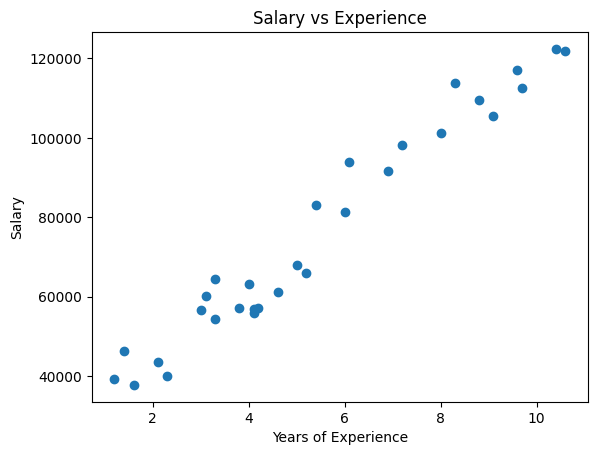

In [7]:
plt.scatter(x, y)
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

A scatter plot depicting our data is shown above. Years of Experience and Salary show a positive linear association, indicating that as a person gets experience, they also earn more money.

##Step 3
Define the model

Our model is:  $$\hat{y} = wx + b$$

In [8]:
def predict(x, w, b):
  return w * x + b

Test it with arbitrary parameters:

In [9]:
# initialize parameters
w = 10000
b = 30000

predictions = predict(x, w, b)
print(predictions[:5])


0    42000.0
1    44000.0
2    46000.0
3    51000.0
4    53000.0
Name: YearsExperience, dtype: float64


##Step 4
 Implement the cost function

In [10]:
def compute_cost(x, y, w, b):
  m = len(x)
  predictions = predict(x, w, b)
  cost = (1/2*m) * np.sum((predictions - y)**2)
  return cost

Test it:

In [11]:
w= 10000
b = 30000
cost = compute_cost(x, y, w,b)
print("cost:", cost)

cost: 44870554980.0


##Step 5
Implement the gradients

In [12]:
def compute_gradients(x, y, w, b):
  m = len(x)
  predictions = predict(x, w, b)
  dw = (1/m) * np.sum((predictions - y) * x)
  db = (1/m) * np.sum((predictions - y))
  return dw, db

Test it:


In [13]:
w = 10000
b = 30000
dw, db = compute_gradients(x, y, w, b)
print("dw,", dw)
print("db,", db)

dw, 48288.919999999984
db, 8129.333333333333


##Step 6
Implement Gradient Descent

In [14]:
def gradient_descent(X, y, w, b, learning_rate, iterations):

    cost_history = []

    for i in range(iterations):

        # Calculate gradients
        dw, db = compute_gradients(X, y, w, b)

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Calculate cost
        cost = compute_cost(X, y, w, b)

        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost}")

    return w, b, cost_history

In [15]:
w = 0
b = 0

learning_rate = 0.01
iterations = 10000

w, b, cost_history = gradient_descent(
    x,
    y,
    w,
    b,
    learning_rate,
    iterations
)

print("Final w:", w)
print("Final b:", b)

Iteration 0: Cost = 1168166896707.2593
Iteration 100: Cost = 46957608531.35669
Iteration 200: Cost = 35865454238.21605
Iteration 300: Cost = 28514620966.986
Iteration 400: Cost = 23643182258.741776
Iteration 500: Cost = 20414852324.9016
Iteration 600: Cost = 18275419852.090145
Iteration 700: Cost = 16857605874.113127
Iteration 800: Cost = 15918012546.586714
Iteration 900: Cost = 15295338743.926195
Iteration 1000: Cost = 14882689299.575174
Iteration 1100: Cost = 14609224183.17612
Iteration 1200: Cost = 14427997306.681065
Iteration 1300: Cost = 14307897232.5048
Iteration 1400: Cost = 14228306235.31878
Iteration 1500: Cost = 14175560832.149712
Iteration 1600: Cost = 14140606155.693441
Iteration 1700: Cost = 14117441494.26796
Iteration 1800: Cost = 14102090142.364353
Iteration 1900: Cost = 14091916714.791208
Iteration 2000: Cost = 14085174726.904026
Iteration 2100: Cost = 14080706773.469042
Iteration 2200: Cost = 14077745835.50369
Iteration 2300: Cost = 14075783605.197958
Iteration 2400: C

After convergence, the estimated parameters were:

Slope (w): 9,449.96
Intercept (b): 24,848.20

These values define the final regression equation:

$$
\hat{y} = 9449.96x + 24848.20
$$

##Step 7
Plot the cost

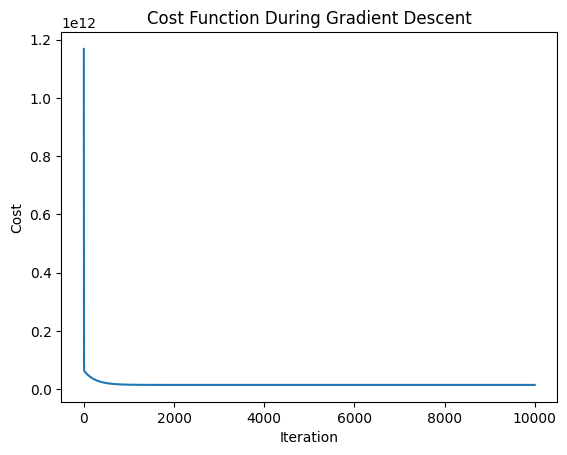

In [16]:
plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function During Gradient Descent")

plt.show()

##Step 8
 Plot your trained regression line

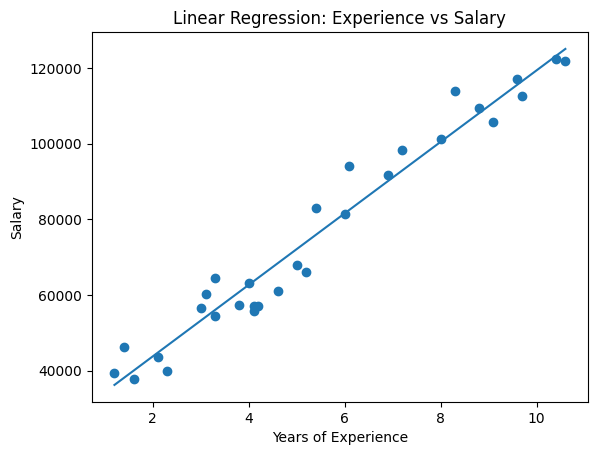

In [17]:
predictions = predict(x, w, b)

plt.scatter(x, y)

plt.plot(x, predictions)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.title("Linear Regression: Experience vs Salary")

plt.show()

##Step 9
Make a prediction

In [18]:
years = 5

predicted_salary = predict(years, w, b)

print(f"Predicted salary: ${predicted_salary:,.2f}")

Predicted salary: $72,098.02


In [19]:
for years in [1, 3, 5, 7, 10]:

    salary = predict(years, w, b)

    print(f"{years} years → ${salary:,.2f}")

1 years → $34,298.17
3 years → $53,198.09
5 years → $72,098.02
7 years → $90,997.94
10 years → $119,347.83


##Step 10
Scikit-learn Linear Regression Implementation

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x.values.reshape(-1, 1), y)

print("Scikit-learn slope:", model.coef_[0])
print("Scikit-learn intercept:", model.intercept_)

Scikit-learn slope: 9449.962321455077
Scikit-learn intercept: 24848.203966523193


## Step 11
Model Comparison: This section compares the slope and intercept obtained from the Gradient Descent and Scikit-learn models to verify that both approaches produce nearly identical results.

In [21]:
comparison = pd.DataFrame({
    "Method": ["Gradient Descent", "Scikit-learn "],
    "Slope (w)": [w, model.coef_[0]],
    "Intercept (b)": [b, model.intercept_]
})

comparison

,Method,Slope (w),Intercept (b)
0,Gradient Descent,9449.962325,24848.203940
1,Scikit-learn,9449.962321,24848.203967


##Step12
Statsmodels OLS Implementation

In [22]:
x_ols = sm.add_constant(x)
model_ols = sm.OLS(y,x_ols).fit()

In [23]:
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.14e-20
Time:                        23:27:51   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.485e+04   2306.654     10.772      0.000    2.01e+04    2.96e+04
YearsExperience  9449.9623    378.755     24.950      0.000    8674.119    1.02e+04
==============================================================================
Omnibus:                        2.140   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.569
Skew:                           0.363   Prob(JB):                        0.456
Kurtosis:                       2.147   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
# Gradient Descent predictions
y_pred_gd = w * x + b

# Scikit-learn predictions
y_pred_sklearn = model.predict(x.values.reshape(-1, 1))

# Statsmodels OLS predictions
y_pred_ols = model_ols.predict(x_ols)

In [26]:
print("Gradient Descent Predictions:")
print(y_pred_gd[:5])

print("\nScikit-learn Predictions:")
print(y_pred_sklearn[:5])

print("\nStatsmodels OLS Predictions:")
print(y_pred_ols[:5])

Gradient Descent Predictions:
0    36188.158730
1    38078.151195
2    39968.143660
3    44693.124823
4    46583.117288
Name: YearsExperience, dtype: float64

Scikit-learn Predictions:
[36188.15875227 38078.15121656 39968.14368085 44693.12484158
 46583.11730587]

Statsmodels OLS Predictions:
0    36188.158752
1    38078.151217
2    39968.143681
3    44693.124842
4    46583.117306
dtype: float64


##Step 13
Model Comparison

In [27]:


comparison = pd.DataFrame({
    "Method": [
        "Gradient Descent",
        "Scikit-learn LinearRegression",
        "Statsmodels OLS"
    ],

    "Slope (w)": [
        w,
        model.coef_[0],
        model_ols.params[1]
    ],

    "Intercept (b)": [
        b,
        model.intercept_,
        model_ols.params[0]
    ]
    })
comparison

/tmp/ipykernel_530/3779847947.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_ols.params[1]
/tmp/ipykernel_530/3779847947.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_ols.params[0]


,Method,Slope (w),Intercept (b)
0,Gradient Descent,9449.962325,24848.203940
1,Scikit-learn LinearRegression,9449.962321,24848.203967
2,Statsmodels OLS,9449.962321,24848.203967


##Conclusion

A simple linear regression model was developed to examine the relationship between Years of Experience and Salary using three different approaches: Gradient Descent, Scikit-learn Linear Regression, and Statsmodels Ordinary Least Squares (OLS).

All three methods produced virtually identical regression coefficients. The estimated slope was approximately 9,449.96, indicating that salary increases by approximately $9,450 for each additional year of experience in this dataset. The estimated intercept was approximately 24,848.20.

Overall, the results demonstrate that the three approaches successfully produce the same linear regression relationship. This comparison also confirms that the Gradient Descent implementation correctly converged to the ordinary least-squares solution.